<h1 style="font-family:verdana;"> <center>Diabetes prediction ML</center> </h1>
<p><center style="color:#159364; font-family:cursive;">Pouya Shokravi</center></p>

***

<div style="font-family:Georgia;line-height:25px;text-align: right" dir="rtl">
<h1> 📘 Project Description </h1>
</br></br>
    
# پروژه پیش‌بینی ابتلا به دیابت

## معرفی پروژه

هدف این پروژه طراحی و پیاده‌سازی یک مدل یادگیری ماشین برای پیش‌بینی ابتلا به دیابت بر اساس اطلاعات پزشکی پایه‌ی بیماران است. این پروژه با استفاده از دیتاست معروف **Pima Indians Diabetes** انجام شده که شامل ۷۶۸ نمونه و ۸ ویژگی عددی (تعداد بارداری، قند خون، فشار خون، ضخامت چین پوست، انسولین، شاخص توده بدنی، شاخص ژنتیکی دیابت و سن) است. متغیر هدف نشان می‌دهد که هر فرد مبتلا به دیابت است یا نه.

## مراحل انجام پروژه

### ۱. بارگذاری و بررسی اولیه داده‌ها
دیتاست بارگذاری شد و با استفاده از `head()`، `info()` و `describe()` ساختار کلی، نوع داده‌ها و آمار توصیفی هر ستون بررسی شد. در این مرحله مشخص شد که اگرچه دیتاست هیچ مقدار `NaN` ندارد، اما برخی ستون‌ها (قند خون، فشار خون، ضخامت پوست، انسولین، شاخص توده بدنی) دارای مقادیر **صفر** هستند که از نظر پزشکی غیرمنطقی‌اند و در واقع نشان‌دهنده‌ی داده‌ی گمشده‌اند.

### ۲. پیش‌پردازش داده‌ها
- تعداد مقادیر صفر غیرمنطقی در هر ستون شمارش شد.
- با کشیدن **هیستوگرام** توزیع هر ستون، شکل توزیع (متقارن یا چوله) بررسی شد تا بهترین روش جایگزینی انتخاب شود.
- برای ستون‌های با توزیع نسبتاً متقارن (قند خون، فشار خون، ضخامت پوست، شاخص توده بدنی) مقادیر صفر با **میانگین**(برسی دقیق برای میانه یا میانگین) جایگزین شدند.
- برای ستون انسولین که توزیع به‌شدت چوله (Right-Skewed) داشت، مقادیر صفر با **میانه** جایگزین شدند تا تأثیر مقادیر پرت کاهش یابد.
- با استفاده از **Box Plot** و **Scatter Plot**، مقادیر پرت (Outlier) هر فیچر بررسی شدند. بیشتر این مقادیر از نظر آماری دور از میانگین بودند اما از نظر پزشکی واقعی و قابل قبول تشخیص داده شدند، به همین دلیل تنها چند سطر مشخصاً مشکوک حذف شدند.

### ۳. تقسیم داده‌ها
داده‌ها با نسبت ۸۰٪ آموزش و ۲۰٪ آزمون تقسیم شدند. از پارامتر `stratify` استفاده شد تا نسبت کلاس‌های دیابتی/غیر دیابتی در هر دو مجموعه حفظ شود (دیتاست نامتوازن است: حدود ۶۵٪ غیر دیابتی و ۳۵٪ دیابتی). همچنین فیچرها با `StandardScaler` استاندارد شدند تا مدل‌های حساس به مقیاس (مانند KNN و SVM) عملکرد درستی داشته باشند.

### ۴. آموزش مدل‌ها
شش مدل طبقه‌بندی مختلف آموزش داده شدند:
- **Logistic Regression** — مدل خطی ساده و قابل تفسیر
- **Decision Tree** — مدل درختی مبتنی بر قواعد تصمیم
- **Random Forest** — ترکیب چندین درخت تصمیم (Ensemble)
- **K-Nearest Neighbors (KNN)** — طبقه‌بندی بر اساس نزدیک‌ترین همسایه‌ها
- **Support Vector Machine (SVM)** — جستجوی بهترین مرز جداکننده بین کلاس‌ها
- **Naive Bayes** — مدل احتمالاتی مبتنی بر قضیه‌ی بیز

### ۵. ارزیابی مدل‌ها
هر مدل با دو معیار ارزیابی شد:
- **Accuracy** — درصد پیش‌بینی‌های درست
- **F1-Score** — معیار مهم‌تر برای این پروژه، به دلیل نامتوازن بودن کلاس‌ها

علاوه بر ارزیابی روی مجموعه آزمون، از **Stratified K-Fold Cross-Validation (k=5)** نیز استفاده شد تا تصویر پایدارتر و قابل‌اعتمادتری از عملکرد هر مدل به‌دست آید.

برای بهبود عملکرد، با استفاده از **GridSearchCV** بهترین ترکیب پارامترهای هر مدل (مانند عمق درخت، تعداد همسایه‌ها، نوع کرنل و وزن‌دهی کلاسی) پیدا شد. وزن‌دهی کلاسی (`class_weight='balanced'`) به‌طور مشخص باعث بهبود F1-Score در بیشتر مدل‌ها شد، چون به مدل کمک می‌کند بیماران دیابتی واقعی را بهتر تشخیص دهد.

### ۶. تحلیل نتایج
نتایج همه‌ی مدل‌ها با Confusion Matrix و نمودارهای مقایسه‌ای بررسی شدند. در نهایت، مدل **Random Forest** (با تنظیمات بهینه‌شده) به‌عنوان بهترین مدل پروژه انتخاب شد، زیرا بالاترین Accuracy و F1-Score را در ارزیابی Cross-Validation داشت و در عین حال پایدارترین عملکرد را بین فولدهای مختلف نشان داد. همچنین نمودار **اهمیت فیچرها (Feature Importance)** نشان داد که قند خون، شاخص توده بدنی و سن از مهم‌ترین عوامل پیش‌بینی دیابت در این مدل هستند.

## نتیجه‌گیری
تمامی شش مدل آموزش‌دیده، حداقل دقت ۷۰٪ مورد نیاز پروژه را پوشش دادند. مدل نهایی منتخب (Random Forest) با دقت حدود ۷۳٪ روی داده آزمون و دقت میانگین **۷۶.۷٪** در Cross-Validation، به‌عنوان مدل پایانی این پروژه ارائه می‌شود.


</div></b>

<a id="1"></a>

</br></br>

# **Table of Contents**💭
1. [Libraries](#1)
2. [Importing dataset](#2)
3. [Prossesing](#3)
4. [Plotting outliers](#4)
5. [Modelling](#5)
6. [grid search](#6)
7. [Mcross validation for all 6 models](#7)
8. [Finall Modell](#8)
9. [Save the Finall Modell](#9)

<a id="home"></a>

<h1 id="1" style="font-family:verdana;"> 
    <center>1.libraries 🎖
    </center>
</h1>

In [445]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

from sklearn.model_selection import GridSearchCV


import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

<h1 id="1" style="font-family:verdana;"> 
    <center>2.Importing dataset 🎖
    </center>
</h1>

In [446]:
data = pd.read_csv("raw.csv")
df_raw = pd.DataFrame(data)
df_raw.head(5)

,pregnancies,plasma glucose concentration,diastolic blood pressure,triceps skinfold thickness,insulin,body mass index,diabetes pedigree function,age,diabetic
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [447]:
df_raw.describe(include='all')

,pregnancies,plasma glucose concentration,diastolic blood pressure,triceps skinfold thickness,insulin,body mass index,diabetes pedigree function,age,diabetic
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000



<div class="alert alert-block alert-info" style="font-size:14px; font-family:verdana;">
    📌 we have invalid 0 in our columns.

In [448]:
list(df_raw.columns)

['pregnancies',
 'plasma glucose concentration',
 'diastolic blood pressure',
 'triceps skinfold thickness',
 'insulin',
 'body mass index',
 'diabetes pedigree function',
 'age',
 'diabetic']

In [449]:
print("column types:")
df_raw.dtypes

column types:


pregnancies                       int64
plasma glucose concentration      int64
diastolic blood pressure          int64
triceps skinfold thickness        int64
insulin                           int64
body mass index                 float64
diabetes pedigree function      float64
age                               int64
diabetic                          int64
dtype: object

In [450]:
print("count of values per column:")
df_raw.count()

count of values per column:


pregnancies                     768
plasma glucose concentration    768
diastolic blood pressure        768
triceps skinfold thickness      768
insulin                         768
body mass index                 768
diabetes pedigree function      768
age                             768
diabetic                        768
dtype: int64

In [451]:
df_raw.shape

(768, 9)

In [452]:
print("Number of null values per column:")
df_raw.isnull().sum()

Number of null values per column:


pregnancies                     0
plasma glucose concentration    0
diastolic blood pressure        0
triceps skinfold thickness      0
insulin                         0
body mass index                 0
diabetes pedigree function      0
age                             0
diabetic                        0
dtype: int64

<h1 id="1" style="font-family:verdana;"> 
    <center>3.Prossesing 🎖
    </center>
</h1>


<div class="alert alert-block alert-info" style="font-size:14px; font-family:verdana;">
    📌 names are too long I can change then.

In [453]:
df1 = df_raw.rename(columns={'plasma glucose concentration' : 'plasma glucose' ,
                             'diastolic blood pressure' : 'blood pressure',
                             'triceps skinfold thickness' : 'skinfold thickness',
                             'body mass index' : 'body mass',
                            'diabetes pedigree function' : 'diabetes pedigree'})
df1.head(5)

,pregnancies,plasma glucose,blood pressure,skinfold thickness,insulin,body mass,diabetes pedigree,age,diabetic
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [454]:
# Define the columns where a value of zero is medically implausible
cols_with_invalid_zeros = [
    "plasma glucose",
    "blood pressure",
    "skinfold thickness",
    "insulin",
    "body mass"
]

# Count how many 0 values exist   
zero_counts = (df1[cols_with_invalid_zeros] == 0).sum()
print("Number of invalid zero values per column:")
print(zero_counts)

Number of invalid zero values per column:
plasma glucose          5
blood pressure         35
skinfold thickness    227
insulin               374
body mass              11
dtype: int64



<div class="alert alert-block alert-info" style="font-size:14px; font-family:verdana;">
    📌skin thickness and insulin have a lot of zero values (alnost half of dataset) so we can not delete them and have to change them whit mean or median

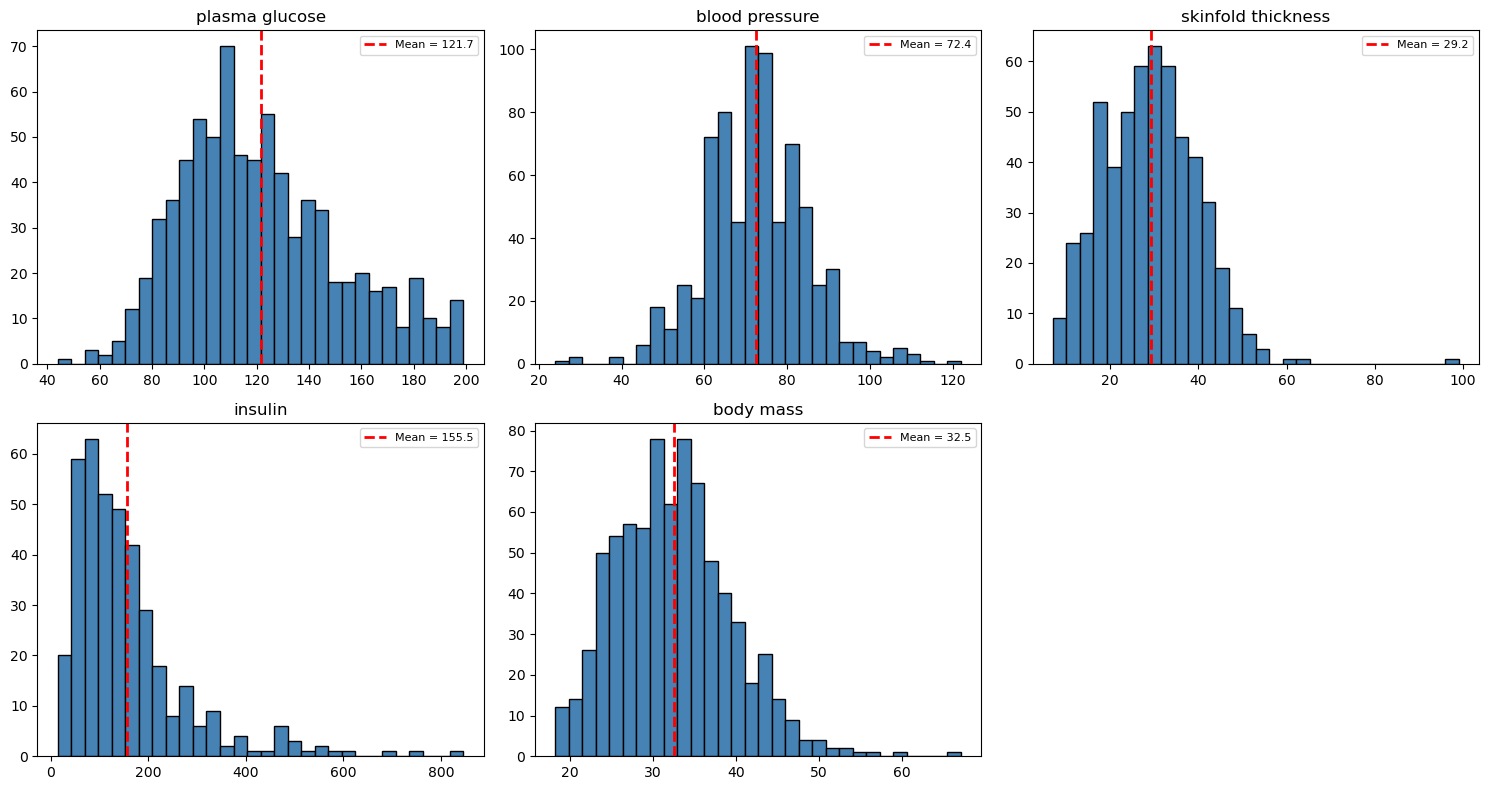

In [455]:
# Visualize the distribution of each column to decide mean or median is more appropriate.
# A skewed distribution (long tail) -> median is better.
# A roughly symmetric/normal distribution -> mean is fine.

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cols_with_invalid_zeros):
    valid_values = df1[df1[col] != 0][col]
    
    axes[i].hist(valid_values, bins=30, color="steelblue", edgecolor="black")
    axes[i].axvline(valid_values.mean(), color="red", linestyle="--", linewidth=2, label=f"Mean = {valid_values.mean():.1f}")
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

# Hide the unused 6th subplot
axes[5].axis("off")

plt.tight_layout()
plt.show()


<div class="alert alert-block alert-info" style="font-size:14px; font-family:verdana;">
    📌only (Insulin) is clearly skewed and it has a long right tail. The other columns are symmetric, so using the mean for them is appropriate and for (insuline) we use median.</br>
when a distribution is skewed, the mean can be distorted by outliers and become misleading

In [456]:
df2 = df1.copy()

In [457]:
mean_cols = ["plasma glucose", "blood pressure", "skinfold thickness", "body mass"]
median_cols = ["insulin"]

In [458]:
# replace columns using the mean
for col in mean_cols:
    calculate_mean = df2[df2[col] != 0][col].mean()
    df2[col] = df2[col].replace(0, calculate_mean)
    print(f"{col}: replaced zeros with (mean) = {calculate_mean:.2f}")

# replace columns using the median
for col in median_cols:
    calculate_median = df2[df2[col] != 0][col].median()
    df2[col] = df2[col].replace(0, calculate_median)
    print(f"{col}: replaced zeros with (median) = {calculate_median:.2f}")

plasma glucose: replaced zeros with (mean) = 121.69
blood pressure: replaced zeros with (mean) = 72.41
skinfold thickness: replaced zeros with (mean) = 29.15
body mass: replaced zeros with (mean) = 32.46
insulin: replaced zeros with (median) = 125.00


In [459]:
print((df2[cols_with_invalid_zeros] == 0).sum())

plasma glucose        0
blood pressure        0
skinfold thickness    0
insulin               0
body mass             0
dtype: int64


In [460]:
list(df2.columns)

['pregnancies',
 'plasma glucose',
 'blood pressure',
 'skinfold thickness',
 'insulin',
 'body mass',
 'diabetes pedigree',
 'age',
 'diabetic']

<h1 id="1" style="font-family:verdana;"> 
    <center>4.Plotting outliers 🎖
    </center>
</h1>

In [461]:
features = ["pregnancies", "plasma glucose", "blood pressure",
                 "skinfold thickness", "insulin", "body mass",
                 "diabetes pedigree", "age"]

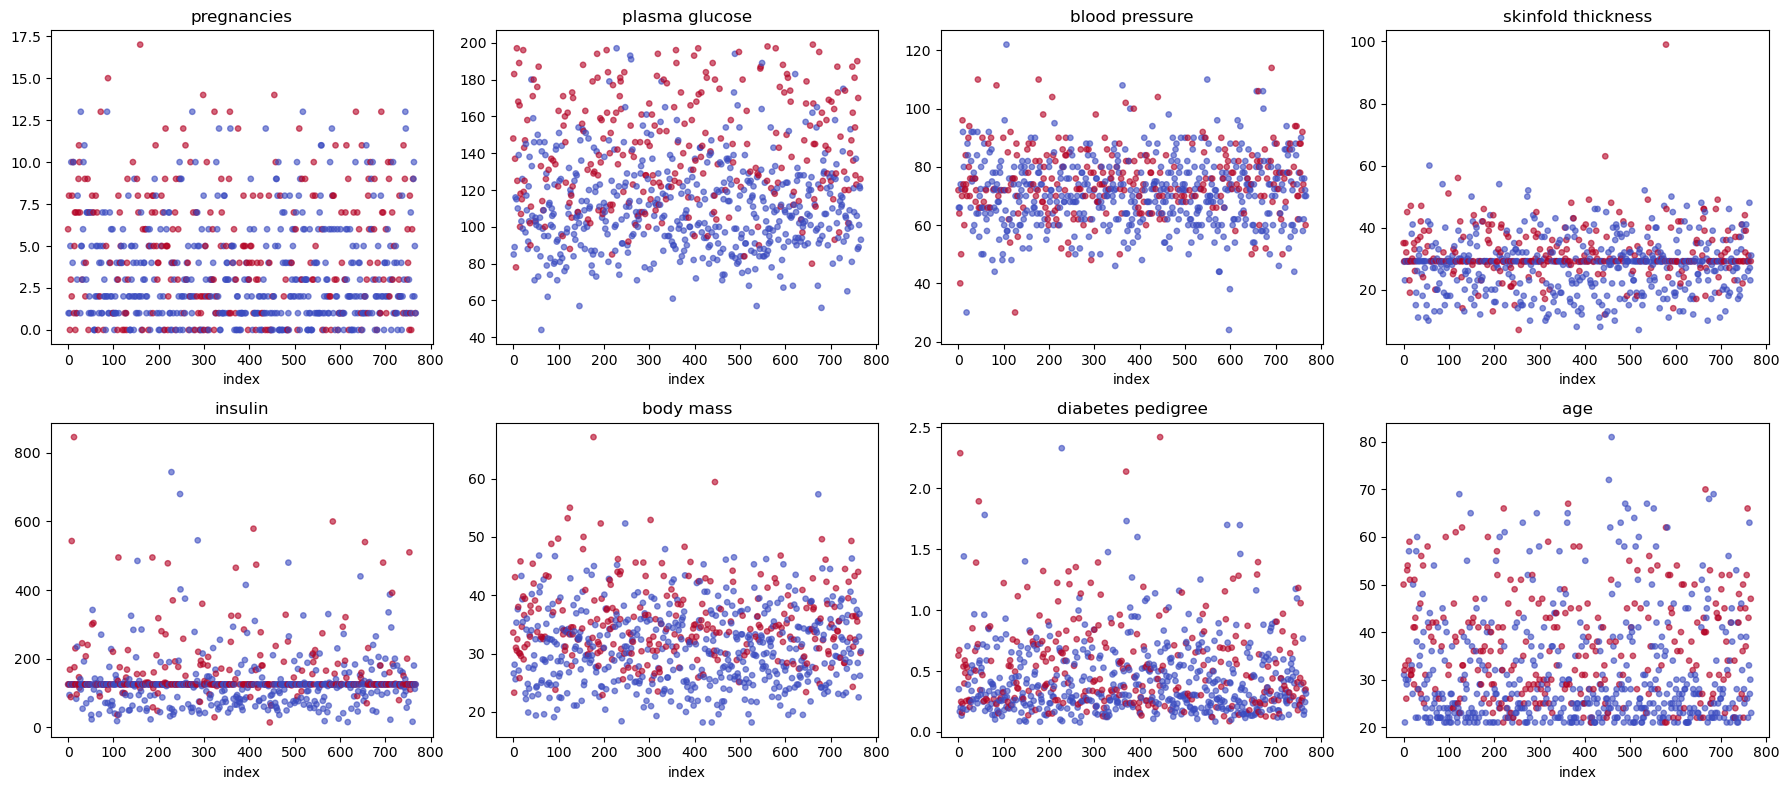

In [462]:
# Scatter plots to find outliers
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    scatter = axes[i].scatter(
        df2.index, df2[col],
        c=df2["diabetic"], cmap="coolwarm", alpha=0.6, s=15
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("index")

plt.tight_layout()
plt.show()

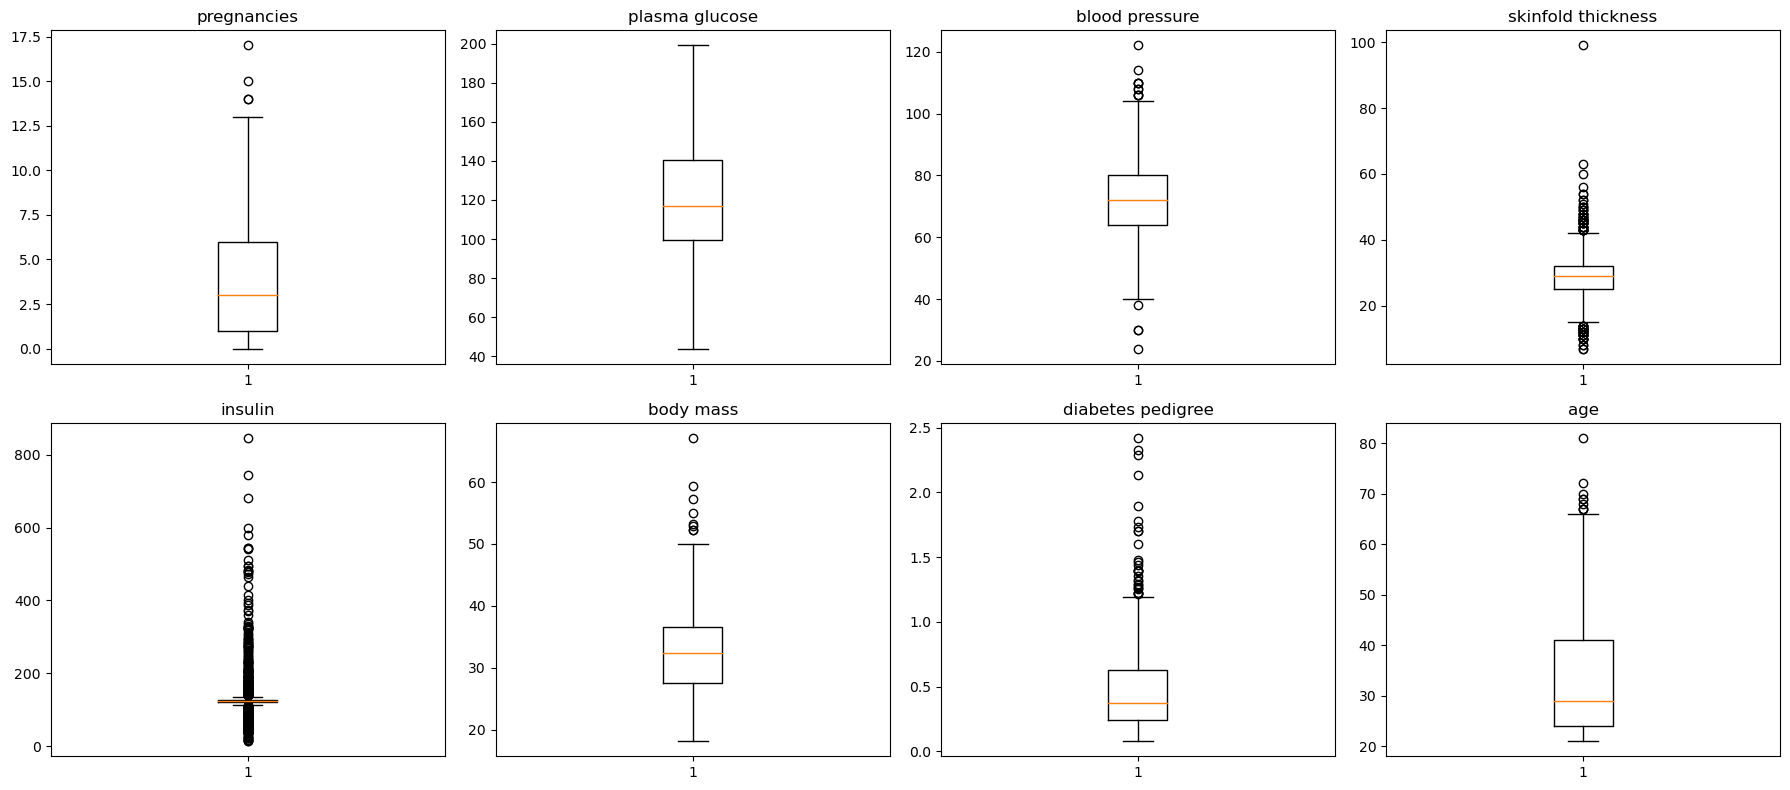

In [463]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].boxplot(df2[col], vert=True)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

## Outlier Analysis Summary

| Feature | Box Plot Observation | Is it a valid outlier? |
|---|---|---|
| **pregnancies** | A few points above 13 (up to 17) | ✅ Valid — a high number of pregnancies (15–17) is rare but physiologically possible |
| **plasma glucose** | No outliers shown) | ✅ No issue |
| **blood pressure** | A few points below 40 and a few above 105 | ⚠️ Low values (near 20–30) are suspicious — a diastolic blood pressure of 20–30 is nearly impossible for a living person |
| **skinfold thickness** | Many outliers close to 100 | ⚠️ A value of 99–100 is clearly unusual (triceps skinfold thickness is typically below 50mm) |
| **insulin** | Many outliers above 800 | ⚠️ Very high values (600–846) are rare but medically possible (severe insulin resistance) — should be treated with caution |
| **body mass** | A few outliers above 50 (up to nearly 70) | ⚠️ A BMI above 60–70 is very rare but **possible** (severe clinical obesity) |
| **diabetes pedigree** | A few outliers above 1.2 | ✅ This is a statistical index, not a direct physical measurement — values of 1.5–2.4 naturally occur |
| **age** | No outliers shown | ✅ No issue |

### Conclusion

Most of these "outliers" are statistically far from the mean but medically rare and real, not data errors. For example, a woman can genuinely have had 17 pregnancies, a diabetic patient can genuinely have insulin levels above 600 (insulin resistance), and a BMI above 50 is rare but seen in severely diabetic patients.

The only genuinely suspicious case is **blood pressure**, with values near 20–30 — this could represent unrecorded/missing data encoded as a small number rather than zero. 

**Decision:** These outliers will **not be removed** I just remove blood pressure <30:

1. Models like Random Forest and Decision Tree are relatively robust to outliers
2. Removing genuine medical outliers could introduce bias (e.g., excluding severely diabetic patients)

In [464]:
blood_pressure_noise = df2[df2['blood pressure']<35]
blood_pressure_noise

,pregnancies,plasma glucose,blood pressure,skinfold thickness,insulin,body mass,diabetes pedigree,age,diabetic
18,1,103.0,30.0,38.0,83,43.3,0.183,33,0
125,1,88.0,30.0,42.0,99,55.0,0.496,26,1
597,1,89.0,24.0,19.0,25,27.8,0.559,21,0


In [465]:
df2.drop(index=[597, 125, 18], inplace=True)

In [466]:
# df2 shape (768-3 = 765) ?
print(f"Shape of df2: {df2.shape}")

Shape of df2: (765, 9)


# Heatmap to find powerfull corolation

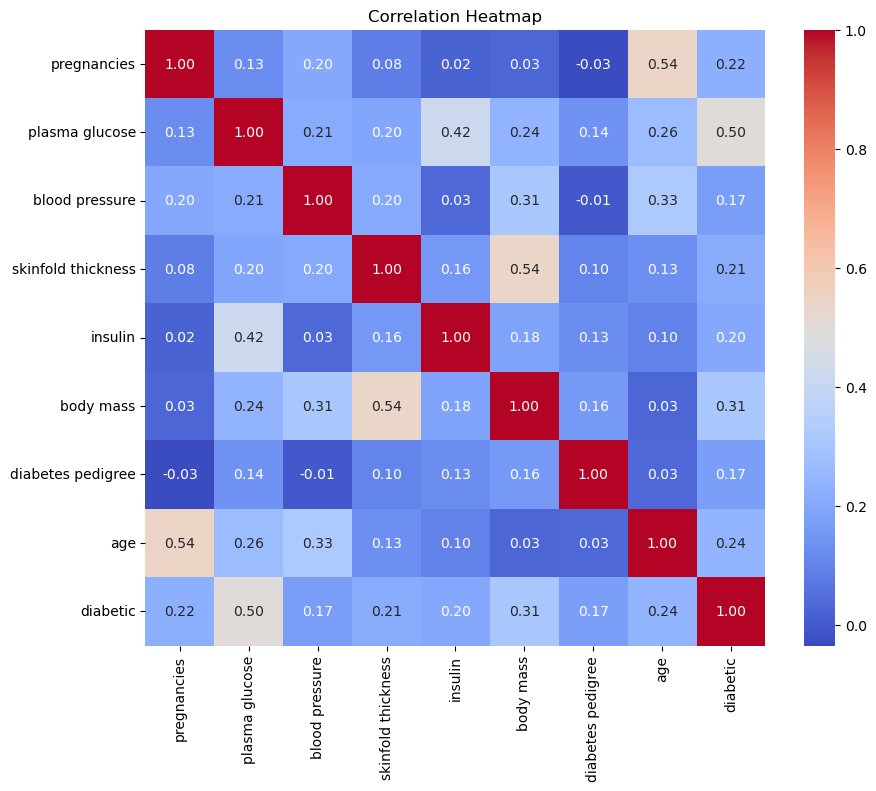

In [467]:
corr = df2.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()


<h1 id="1" style="font-family:verdana;"> 
    <center>5.Modelling 🎖
    </center>
</h1>

In [468]:
X = df2.drop(columns=["diabetic"])
y = df2["diabetic"]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (765, 8)
y shape: (765,)


In [469]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state = 42, stratify=y)

# Standardize features


In [470]:
# Standardize features
# This is important for distance-based models like KNN and SVM,

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train_scaled shape: {X_train_scaled.shape}")

X_train_scaled shape: (612, 8)


<p style="background-color:powderblue; font-family:roboto; color:navy; font-size:145%;font-weight:bold; text-align:center; border-radius:25px 10px; padding: 10px">1 -  Logistic Regression</p>

In [471]:
# Train a Logistic Regression model
logreg = LogisticRegression(random_state=42, max_iter=1000, solver='lbfgs', penalty='l2')
logreg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [472]:
# Make predictions on the test set
y_pred_log_reg = logreg.predict(X_test_scaled)

In [473]:
acc_log_reg = accuracy_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)

print(f"Accuracy: {acc_log_reg:.4f}")
print(f"F1-Score: {f1_log_reg:.4f}")
print()
print("Detailed classification report:")
print(classification_report(y_test, y_pred_log_reg))

Accuracy: 0.7386
F1-Score: 0.5455

Detailed classification report:
              precision    recall  f1-score   support

           0       0.75      0.89      0.82       100
           1       0.69      0.45      0.55        53

    accuracy                           0.74       153
   macro avg       0.72      0.67      0.68       153
weighted avg       0.73      0.74      0.72       153



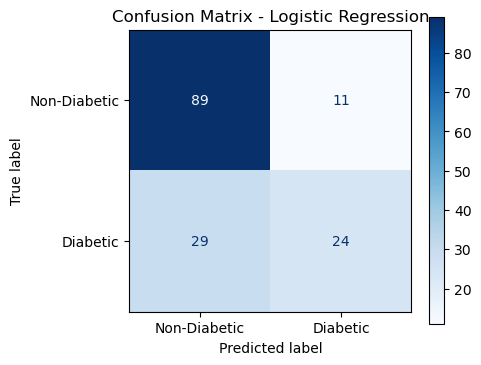

In [474]:
#confusion matrix for Logistic Regression
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_log_reg, display_labels=["Non-Diabetic", "Diabetic"])
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()

<p style="background-color:powderblue; font-family:roboto; color:navy; font-size:145%;font-weight:bold; text-align:center; border-radius:25px 10px; padding: 10px">2 - DecisionTree</p>

In [475]:
tree_clf = DecisionTreeClassifier(random_state=42, criterion='entropy')
tree_clf.fit(X_train_scaled, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [476]:
y_pred_tree = tree_clf.predict(X_test_scaled)

In [477]:
acc_tree = accuracy_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

print(f"Accuracy: {acc_tree:.4f}")
print(f"F1-Score: {f1_tree:.4f}")
print()
print("Detailed classification report:")
print(classification_report(y_test, y_pred_tree))

Accuracy: 0.7255
F1-Score: 0.6038

Detailed classification report:
              precision    recall  f1-score   support

           0       0.79      0.79      0.79       100
           1       0.60      0.60      0.60        53

    accuracy                           0.73       153
   macro avg       0.70      0.70      0.70       153
weighted avg       0.73      0.73      0.73       153



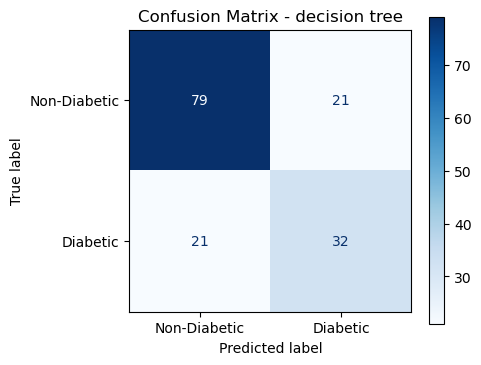

In [478]:
#confusion matrix for decision tree
cm_tree = confusion_matrix(y_test, y_pred_tree)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=["Non-Diabetic", "Diabetic"])
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Confusion Matrix - decision tree")
plt.tight_layout()
plt.show()

<p style="background-color:powderblue; font-family:roboto; color:navy; font-size:145%;font-weight:bold; text-align:center; border-radius:25px 10px; padding: 10px">3 -  random forest</p>

In [479]:
rf_clf = RandomForestClassifier(random_state=42, n_estimators=100,criterion='entropy',bootstrap=True)
rf_clf.fit(X_train_scaled, y_train)

RandomForestClassifier(criterion='entropy', random_state=42)

In [480]:
y_pred_rf = rf_clf.predict(X_test_scaled)


In [481]:
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"Accuracy: {acc_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")
print()
print("Detailed classification report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7451
F1-Score: 0.6061

Detailed classification report:
              precision    recall  f1-score   support

           0       0.79      0.84      0.81       100
           1       0.65      0.57      0.61        53

    accuracy                           0.75       153
   macro avg       0.72      0.70      0.71       153
weighted avg       0.74      0.75      0.74       153



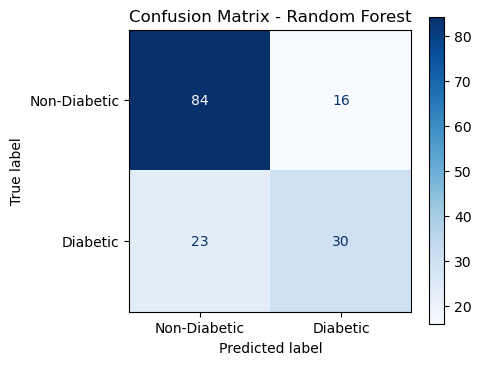

In [482]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Non-Diabetic", "Diabetic"])
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()

<p style="background-color:powderblue; font-family:roboto; color:navy; font-size:145%;font-weight:bold; text-align:center; border-radius:25px 10px; padding: 10px">4 -  knn</p>

In [483]:
knn_clf = KNeighborsClassifier(n_neighbors=21, metric='euclidean')
knn_clf.fit(X_train_scaled, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=21)

In [484]:
y_pred_knn = knn_clf.predict(X_test_scaled)

In [485]:
acc_knn = accuracy_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

print(f"Accuracy: {acc_knn:.4f}")
print(f"F1-Score: {f1_knn:.4f}")
print()
print("Detailed classification report:")
print(classification_report(y_test, y_pred_knn))

Accuracy: 0.7255
F1-Score: 0.5625

Detailed classification report:
              precision    recall  f1-score   support

           0       0.76      0.84      0.80       100
           1       0.63      0.51      0.56        53

    accuracy                           0.73       153
   macro avg       0.70      0.67      0.68       153
weighted avg       0.72      0.73      0.72       153



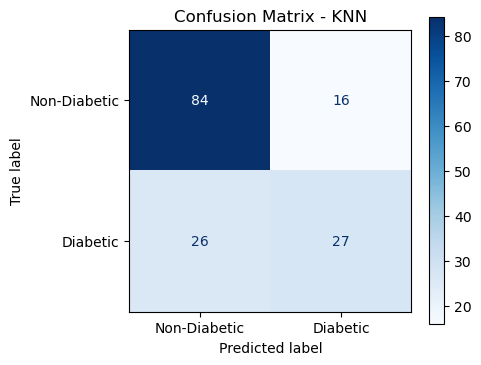

In [486]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=["Non-Diabetic", "Diabetic"])
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Confusion Matrix - KNN")
plt.tight_layout()
plt.show()

<p style="background-color:powderblue; font-family:roboto; color:navy; font-size:145%;font-weight:bold; text-align:center; border-radius:25px 10px; padding: 10px">5 -  svm</p>

In [487]:
svm_clf = SVC(kernel="linear", random_state=42, probability=True, C=0.1)
svm_clf.fit(X_train_scaled, y_train)

SVC(C=0.1, kernel='linear', probability=True, random_state=42)

In [488]:
y_pred_svm = svm_clf.predict(X_test_scaled)

In [489]:
acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print(f"Accuracy: {acc_svm:.4f}")
print(f"F1-Score: {f1_svm:.4f}")
print()
print("Detailed classification report:")
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.7451
F1-Score: 0.5412

Detailed classification report:
              precision    recall  f1-score   support

           0       0.75      0.91      0.82       100
           1       0.72      0.43      0.54        53

    accuracy                           0.75       153
   macro avg       0.74      0.67      0.68       153
weighted avg       0.74      0.75      0.73       153



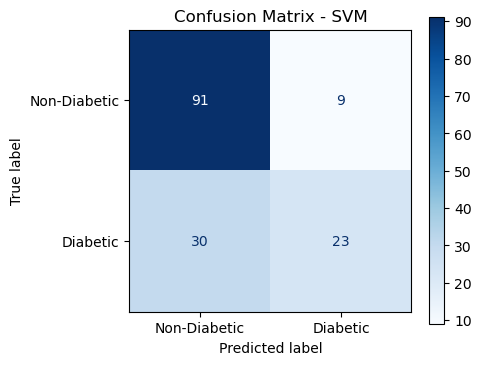

In [490]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=["Non-Diabetic", "Diabetic"])
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Confusion Matrix - SVM")
plt.tight_layout()
plt.show()

<p style="background-color:powderblue; font-family:roboto; color:navy; font-size:145%;font-weight:bold; text-align:center; border-radius:25px 10px; padding: 10px">6 -  naive baise</p>

In [491]:
nb_clf = GaussianNB()
nb_clf.fit(X_train_scaled, y_train)

GaussianNB()

In [492]:
y_pred_nb = nb_clf.predict(X_test_scaled)

In [493]:
acc_nb = accuracy_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print(f"Accuracy: {acc_nb:.4f}")
print(f"F1-Score: {f1_nb:.4f}")
print()
print("Detailed classification report:")
print(classification_report(y_test, y_pred_nb))

Accuracy: 0.7124
F1-Score: 0.5417

Detailed classification report:
              precision    recall  f1-score   support

           0       0.75      0.83      0.79       100
           1       0.60      0.49      0.54        53

    accuracy                           0.71       153
   macro avg       0.68      0.66      0.67       153
weighted avg       0.70      0.71      0.70       153



In [494]:
kfold = KFold(5)
results = cross_val_score(rf_clf, X, y, cv = kfold)
print(results)
print(np.mean(results))

[0.77124183 0.69281046 0.75163399 0.83006536 0.74509804]
0.758169934640523


<h1 id="1" style="font-family:verdana;"> 
    <center>6.grid search 🎖
    </center>
</h1>

In [495]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

<p style="background-color:deepskyblue  ; font-family:roboto; color:navy; font-size:145%;font-weight:bold; text-align:center; border-radius:25px 10px; padding: 10px">1 -  Logistic Regression</p>

In [496]:
param_grid_lr = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "class_weight": [None, "balanced"],
    "solver": ["liblinear"]  # liblinear supports both l1 and l2
}

grid_lr = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid_lr, cv=cv_strategy, scoring="f1", n_jobs=-1
)
grid_lr.fit(X_train_scaled, y_train)

print("Best params (Logistic Regression):", grid_lr.best_params_)
print("Best CV F1-Score:", grid_lr.best_score_)

# Evaluate the best model on the test set
best_lr = grid_lr.best_estimator_
y_pred_best_lr = best_lr.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_pred_best_lr))
print("Test F1-Score:", f1_score(y_test, y_pred_best_lr))

Best params (Logistic Regression): {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Best CV F1-Score: 0.695345890755899
Test Accuracy: 0.7320261437908496
Test F1-Score: 0.6238532110091742


<p style="background-color:deepskyblue ; font-family:roboto; color:navy; font-size:145%;font-weight:bold; text-align:center; border-radius:25px 10px; padding: 10px">2 - DecisionTree</p>

In [497]:
param_grid_dt = {
    "max_depth": [3, 4, 5, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 5, 10, 20],
    "criterion": ["gini", "entropy"],
    "class_weight": [None, "balanced"]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt, cv=cv_strategy, scoring="f1", n_jobs=-1
)
grid_dt.fit(X_train_scaled, y_train)

print("Best params (Decision Tree):", grid_dt.best_params_)
print("Best CV F1-Score:", grid_dt.best_score_)

best_dt = grid_dt.best_estimator_
y_pred_best_dt = best_dt.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_pred_best_dt))
print("Test F1-Score:", f1_score(y_test, y_pred_best_dt))

Best params (Decision Tree): {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 20, 'min_samples_split': 2}
Best CV F1-Score: 0.6946867604056414
Test Accuracy: 0.6928104575163399
Test F1-Score: 0.6050420168067228


<p style="background-color:deepskyblue ; font-family:roboto; color:navy; font-size:145%;font-weight:bold; text-align:center; border-radius:25px 10px; padding: 10px">3 -  random forest</p>

In [498]:
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 8, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf, cv=cv_strategy, scoring="f1", n_jobs=-1
)
grid_rf.fit(X_train_scaled, y_train)

print("Best params (Random Forest):", grid_rf.best_params_)
print("Best CV F1-Score:", grid_rf.best_score_)

best_rf = grid_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_pred_best_rf))
print("Test F1-Score:", f1_score(y_test, y_pred_best_rf))

Best params (Random Forest): {'class_weight': 'balanced', 'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}
Best CV F1-Score: 0.7101941477750517
Test Accuracy: 0.7320261437908496
Test F1-Score: 0.6554621848739496


<p style="background-color:deepskyblue ; font-family:roboto; color:navy; font-size:145%;font-weight:bold; text-align:center; border-radius:25px 10px; padding: 10px">4 -  knn</p>

In [499]:
param_grid_knn = {
    "n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn, cv=cv_strategy, scoring="f1", n_jobs=-1
)
grid_knn.fit(X_train_scaled, y_train)

print("Best params (KNN):", grid_knn.best_params_)
print("Best CV F1-Score:", grid_knn.best_score_)

best_knn = grid_knn.best_estimator_
y_pred_best_knn = best_knn.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_pred_best_knn))
print("Test F1-Score:", f1_score(y_test, y_pred_best_knn))

Best params (KNN): {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}
Best CV F1-Score: 0.6583106735427411
Test Accuracy: 0.7058823529411765
Test F1-Score: 0.5454545454545454


<p style="background-color:deepskyblue ; font-family:roboto; color:navy; font-size:145%;font-weight:bold; text-align:center; border-radius:25px 10px; padding: 10px">5 -  svm</p>

In [500]:
param_grid_svm = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["rbf", "linear"],
    "gamma": ["scale", "auto", 0.01, 0.1, 1],
    "class_weight": [None, "balanced"]
}

grid_svm = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid_svm, cv=cv_strategy, scoring="f1", n_jobs=-1
)
grid_svm.fit(X_train_scaled, y_train)

print("Best params (SVM):", grid_svm.best_params_)
print("Best CV F1-Score:", grid_svm.best_score_)

best_svm = grid_svm.best_estimator_
y_pred_best_svm = best_svm.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_pred_best_svm))
print("Test F1-Score:", f1_score(y_test, y_pred_best_svm))

Best params (SVM): {'C': 1, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'linear'}
Best CV F1-Score: 0.69433243085417
Test Accuracy: 0.7058823529411765
Test F1-Score: 0.5794392523364486


<p style="background-color:deepskyblue ; font-family:roboto; color:navy; font-size:145%;font-weight:bold; text-align:center; border-radius:25px 10px; padding: 10px">6 -  naive baise</p>

In [501]:
param_grid_nb = {
    "var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4]
}

grid_nb = GridSearchCV(
    GaussianNB(),
    param_grid_nb, cv=cv_strategy, scoring="f1", n_jobs=-1
)
grid_nb.fit(X_train_scaled, y_train)

print("Best params (Naive Bayes):", grid_nb.best_params_)
print("Best CV F1-Score:", grid_nb.best_score_)

best_nb = grid_nb.best_estimator_
y_pred_best_nb = best_nb.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_pred_best_nb))
print("Test F1-Score:", f1_score(y_test, y_pred_best_nb))

Best params (Naive Bayes): {'var_smoothing': 1e-09}
Best CV F1-Score: 0.6539300057372346
Test Accuracy: 0.7124183006535948
Test F1-Score: 0.5416666666666665


<h1 id="1" style="font-family:verdana;"> 
    <center>7. cross validation for all 6 models 🎖
    </center>
</h1>

In [502]:
# Evaluate all tuned (best) models using 5-fold Stratified Cross-Validation
# on the FULL dataset, for a more reliable performance estimate.

tuned_models = {
    "Logistic Regression (Tuned)": best_lr,
    "Decision Tree (Tuned)": best_dt,
    "Random Forest (Tuned)": best_rf,
    "KNN (Tuned)": best_knn,
    "SVM (Tuned)": best_svm,
    "Naive Bayes (Tuned)": best_nb
}

cv_tuned_results = {}

for name, model in tuned_models.items():
    acc_scores = cross_val_score(model, X_full_scaled, y_full, cv=cv_strategy, scoring="accuracy")
    f1_scores = cross_val_score(model, X_full_scaled, y_full, cv=cv_strategy, scoring="f1")
    
    cv_tuned_results[name] = {
        "CV Accuracy Mean": acc_scores.mean(),
        "CV Accuracy Std": acc_scores.std(),
        "CV F1 Mean": f1_scores.mean(),
        "CV F1 Std": f1_scores.std()
    }
    
    print(f"{name}:")
    print(f"  CV Accuracy: {acc_scores.mean():.4f} (+/- {acc_scores.std():.4f})")
    print(f"  CV F1-Score: {f1_scores.mean():.4f} (+/- {f1_scores.std():.4f})")
    print()

Logistic Regression (Tuned):
  CV Accuracy: 0.7490 (+/- 0.0158)
  CV F1-Score: 0.6671 (+/- 0.0280)

Decision Tree (Tuned):
  CV Accuracy: 0.7412 (+/- 0.0221)
  CV F1-Score: 0.6777 (+/- 0.0310)

Random Forest (Tuned):
  CV Accuracy: 0.7673 (+/- 0.0168)
  CV F1-Score: 0.7011 (+/- 0.0232)

KNN (Tuned):
  CV Accuracy: 0.7542 (+/- 0.0288)
  CV F1-Score: 0.6181 (+/- 0.0508)

SVM (Tuned):
  CV Accuracy: 0.7516 (+/- 0.0245)
  CV F1-Score: 0.6632 (+/- 0.0396)

Naive Bayes (Tuned):
  CV Accuracy: 0.7529 (+/- 0.0259)
  CV F1-Score: 0.6281 (+/- 0.0372)



In [503]:
kfold = KFold(5)
results = cross_val_score(best_rf, X, y, cv = kfold)
print(results)
print(np.mean(results))

[0.73202614 0.7254902  0.80392157 0.81045752 0.75816993]
0.7660130718954248


<h1 id="1" style="font-family:verdana;"> 
    <center>8. Finall Modell 🎖
    </center>
</h1>

## Final Model Comparison

| Model | Test Acc (Tuned) | Test F1 (Tuned) | CV Acc (Tuned) | CV F1 (Tuned) |
|---|---|---|---|---|
| Logistic Regression | 73.20% | 0.6238 | 74.90% ± 1.58% | 0.6671 ± 0.0280 |
| Decision Tree | 69.28% | 0.6050 | 74.12% ± 2.21% | 0.6777 ± 0.0310 |
| 🏆 **Random Forest** | **73.20%** | **0.6555** | **76.73% ± 1.68%** | **0.7011 ± 0.0232** |
| KNN | 70.59% | 0.5455 | 75.42% ± 2.88% | 0.6181 ± 0.0508 |
| SVM | 70.59% | 0.5794 | 75.16% ± 2.45% | 0.6632 ± 0.0396 |
| Naive Bayes | 71.24% | 0.5417 | 75.29% ± 2.59% | 0.6281 ± 0.0372 |

### Final Model Selection

The **Random Forest** model was selected as the final model for this project:

1. **Highest Cross-Validation Accuracy (76.73%)** — 

2. **Highest Cross-Validation F1-Score (0.7011)** —  the most important metric for this imbalanced dataset (65% non-diabetic / 35% diabetic).


In [504]:
print("Final selected parameters for Random Forest:")
print(grid_rf.best_params_)

Final selected parameters for Random Forest:
{'class_weight': 'balanced', 'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}


In [505]:
# Train the FINAL Random Forest model using the best hyperparameters

final_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    max_features="log2",
    min_samples_leaf=4,
    min_samples_split=2,
    class_weight="balanced",
    random_state=42
)

final_model.fit(X_full_scaled, y_full)

RandomForestClassifier(class_weight='balanced', max_depth=5,
                       max_features='log2', min_samples_leaf=4,
                       n_estimators=300, random_state=42)

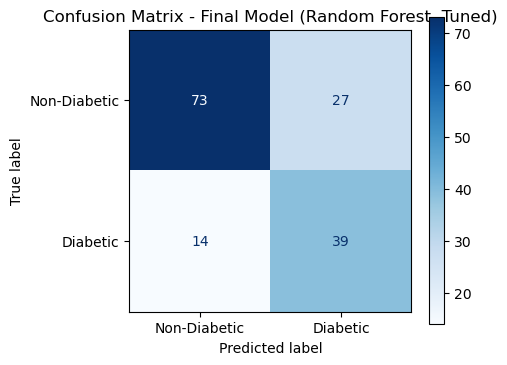

In [506]:
# Confusion Matrix
cm_final = confusion_matrix(y_test, y_pred_best_rf)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=["Non-Diabetic", "Diabetic"])
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Confusion Matrix - Final Model (Random Forest, Tuned)")
plt.tight_layout()
plt.show()

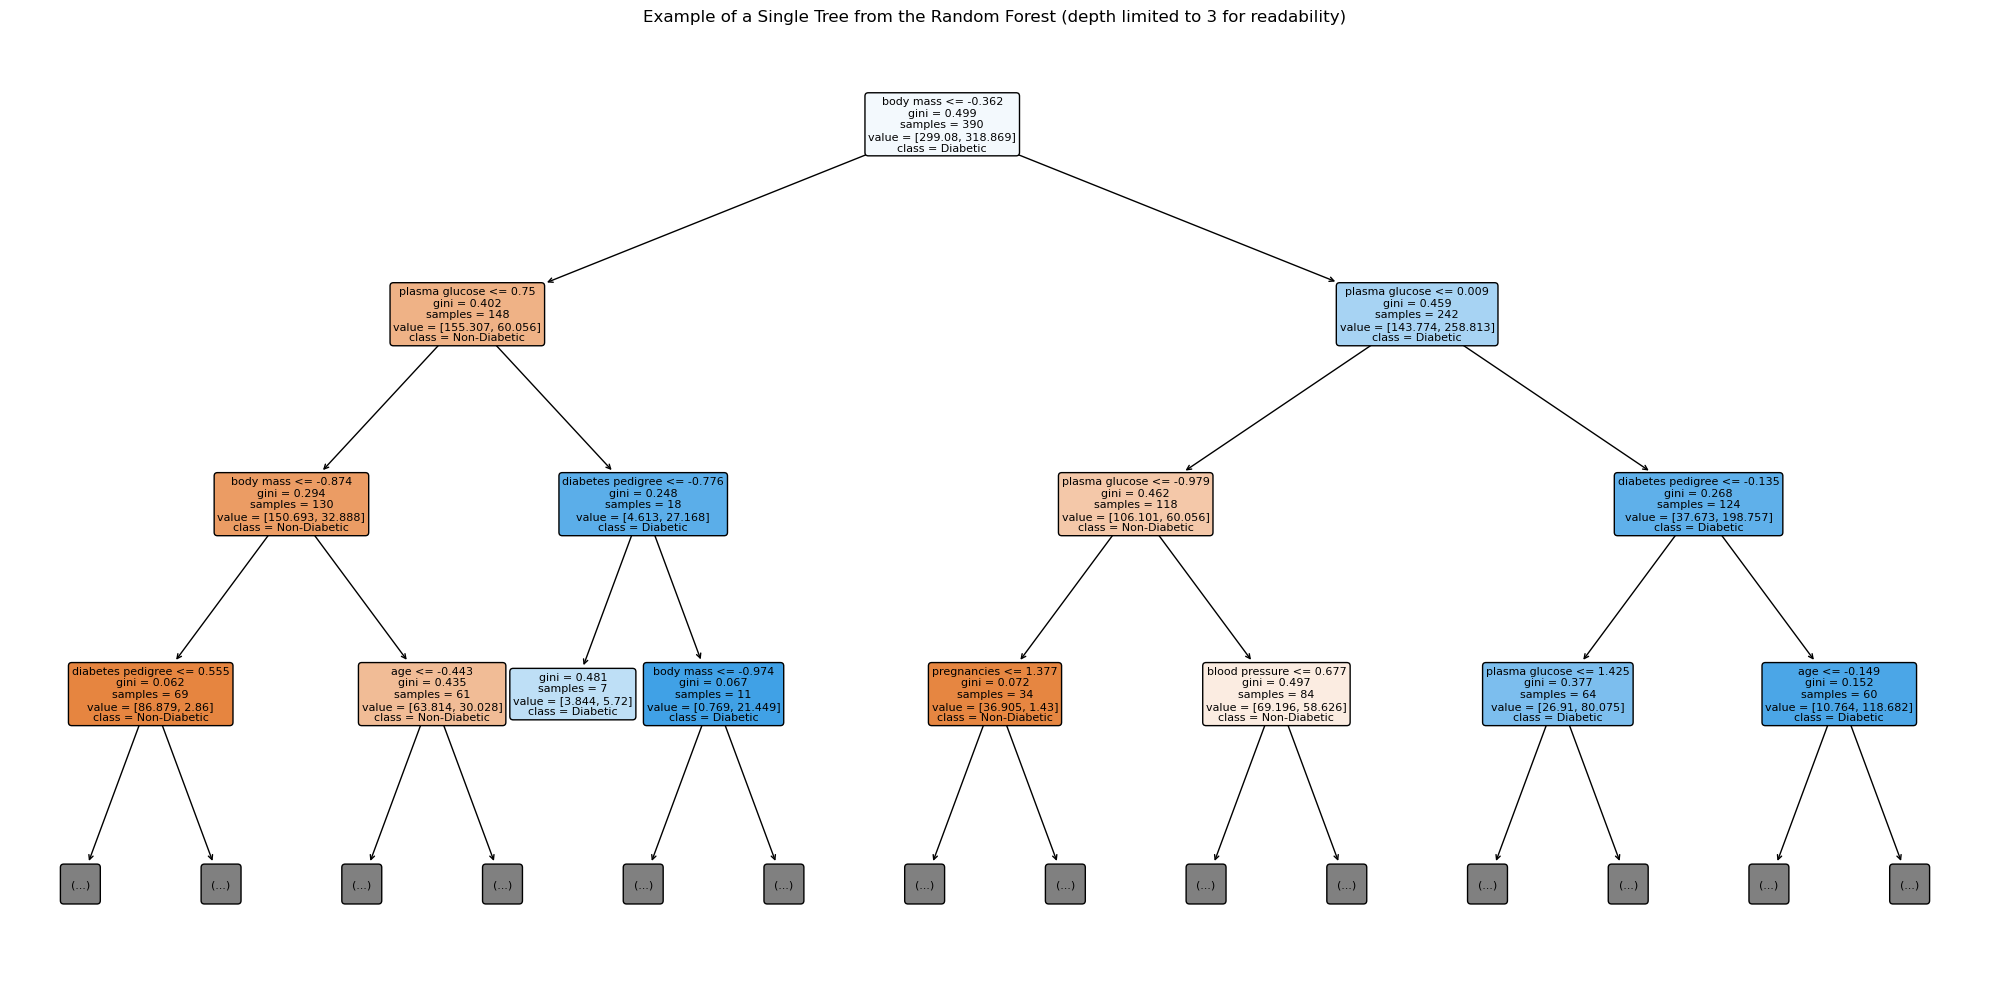

In [507]:
from sklearn.tree import plot_tree

#visualizing first Random Forest tree
fig, ax = plt.subplots(figsize=(20, 10))

plot_tree(
    best_rf.estimators_[0],
    feature_names=list(X.columns),    # convert pandas Index to a plain list
    class_names=["Non-Diabetic", "Diabetic"],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3,
    ax=ax
)

ax.set_title("Example of a Single Tree from the Random Forest (depth limited to 3 for readability)")
plt.tight_layout()
plt.show()

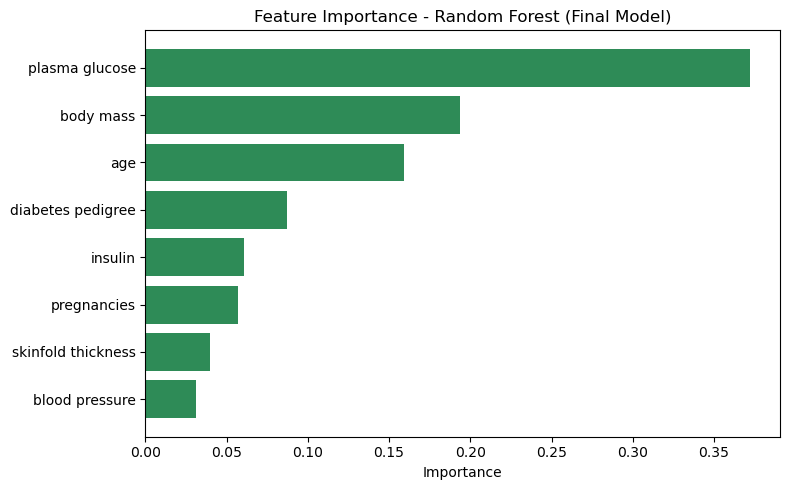

In [508]:
# Feature importance from the final Random Forest model
importances = best_rf.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance_df["Feature"], importance_df["Importance"], color="seagreen")
ax.set_xlabel("Importance")
ax.set_title("Feature Importance - Random Forest (Final Model)")
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info" style="font-size:14px; font-family:verdana;">
    📌 we can see that plasma glucose has the most effect


<h1 id="1" style="font-family:verdana;"> 
    <center>9. Save the Finall Modell 🎖
    </center>
</h1>

In [509]:
import joblib
joblib.dump(final_model, "final_diabetes_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully.")

Model and scaler saved successfully.
